In [ ]:
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import adjusted_rand_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

from helpers import *

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

In [40]:
# File paths
comparison_path = f"../output/MERSCOPE_WT_AD_comparison/"

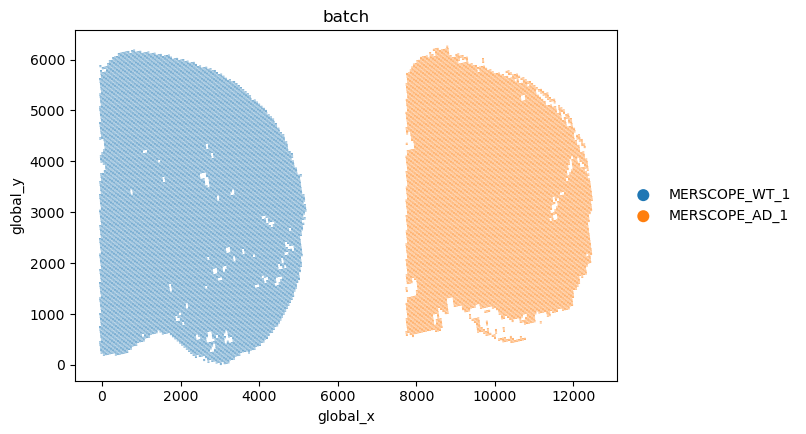

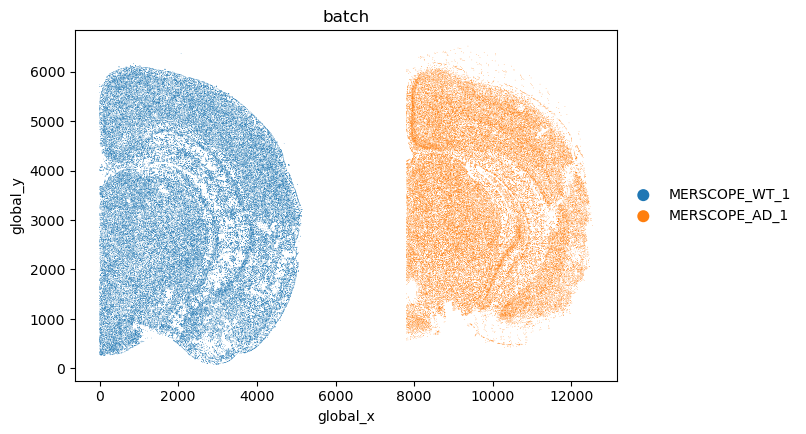

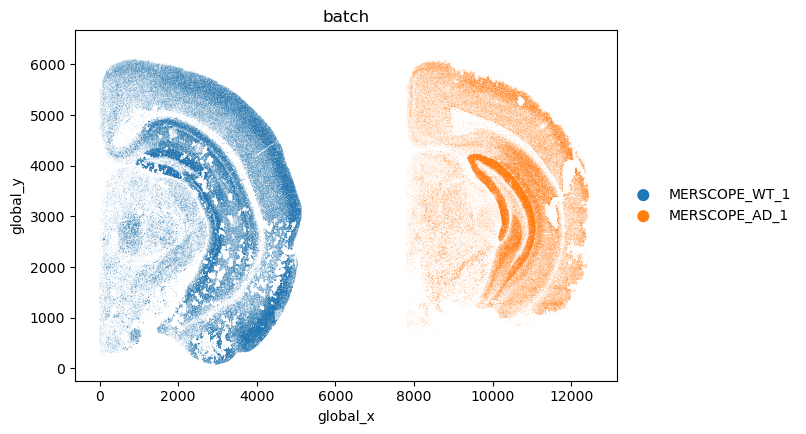

In [41]:
# ==================== Read data ==================== #

# # Transcripts
# transcripts = pd.read_parquet(comparison_path + "neuropil_subdomains_transcripts.parquet")

# Spots
spots = sc.read_h5ad(comparison_path + "neuropil_subdomains_spots.h5ad")
spots = spots[spots.obs["brain_area"] != "Unknown"].copy()

# Cells
adata = sc.read_h5ad(comparison_path + "neuropil_subdomains_adata.h5ad")

# Granules
granule_adata = sc.read_h5ad(comparison_path + "neuropil_subdomains_granule_adata.h5ad")

# Plot check
# transcripts_downsampled = transcripts.sample(10000)
# unique_batches = ["MERSCOPE_WT_1", "MERSCOPE_AD_1"]
# colors = plt.cm.tab10(range(len(unique_batches)))
# color_map = dict(zip(unique_batches, colors))
# plt.scatter(transcripts_downsampled["global_x"], transcripts_downsampled["global_y"], c = transcripts_downsampled["batch"].map(color_map), s = 0.1)
# plt.show()

sc.pl.scatter(spots, x="global_x", y="global_y", color="batch")
plt.show()

sc.pl.scatter(adata, x="global_x", y="global_y", color="batch")
plt.show()

sc.pl.scatter(granule_adata, x="global_x", y="global_y", color="batch")
plt.show()

In [42]:
# Compute grid-level embeddings
embeddings, feature_names, aux = spot_embedding_granule_subtype_counts(
    spots=spots,
    granule_adata=granule_adata,
    adata=adata,
    include_soma_features=True,
    smoothing=True,
    smoothing_radius=np.sqrt(2) * 25 + 1,
    smoothing_mode="mean"
)

for aux_key, aux_val in aux.items():
    spots.obs[aux_key] = aux_val

In [43]:
X = np.log1p(embeddings)
X = StandardScaler().fit_transform(X)

In [ ]:
# range of K
k_range = range(3, 16)

inertias = []

for k in k_range:
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=0,
        batch_size=5000
    )
    km.fit(X)
    inertias.append(km.inertia_)

# convert to array
inertias = np.array(inertias)

In [45]:
K = 5

# K-Means
kmeans = MiniBatchKMeans(n_clusters=K, batch_size=5000, random_state=0, n_init=20)
kmeans.fit(X)
spots.obs["subdomain_kmeans"] = kmeans.labels_.astype(str)
spots.obs["subdomain_kmeans"].value_counts()

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=0)
labels = gmm.fit_predict(X)
spots.obs["subdomain_gmm"] = labels.astype(str)
spots.obs["subdomain_gmm"].value_counts()

# Latent Dirichlet Allocation
lda = LatentDirichletAllocation(n_components=K, random_state=0)
theta = lda.fit_transform(embeddings)
labels = theta.argmax(axis=1)
spots.obs["subdomain_lda"] = labels.astype(str)
spots.obs["subdomain_lda"].value_counts()

subdomain_lda
4    34366
0    21658
1     8163
3     6769
2     5004
Name: count, dtype: int64

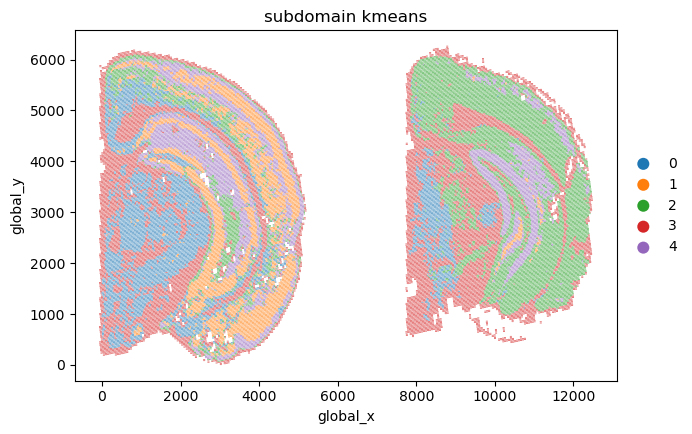

In [46]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="subdomain_kmeans")
plt.show()

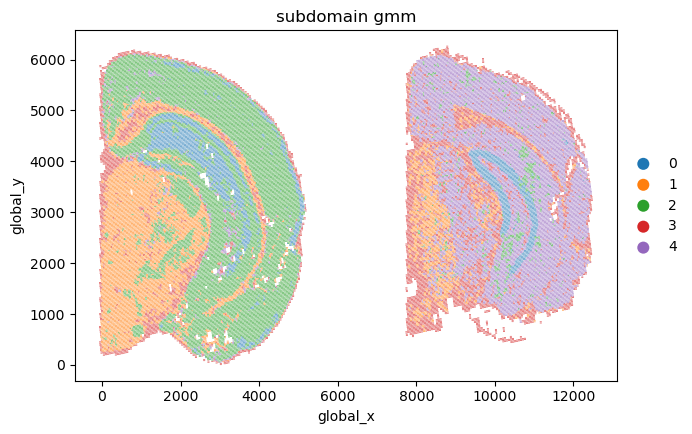

In [47]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="subdomain_gmm")
plt.show()

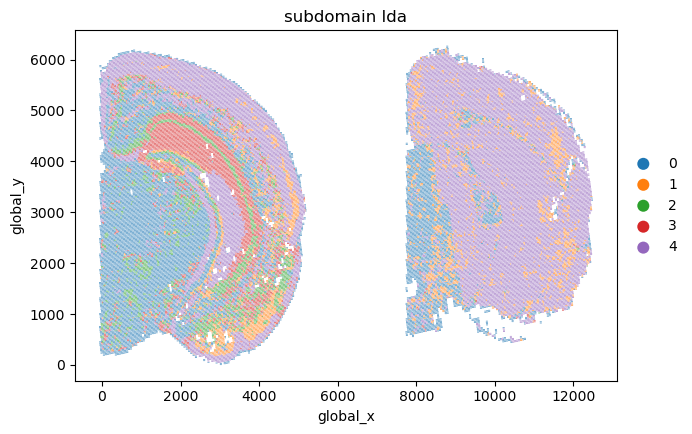

In [48]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="subdomain_lda")
plt.show()

In [21]:
# embeddings_norm = np.log1p(embeddings)

row_sums = embeddings.sum(axis=1, keepdims=True)
embeddings_norm = np.divide(embeddings, row_sums, out=np.zeros_like(embeddings), where=row_sums > 0)

In [23]:
np.sum(embeddings_norm.sum(axis=1) > 0) / embeddings_norm.shape[0]

0.9614007372301211

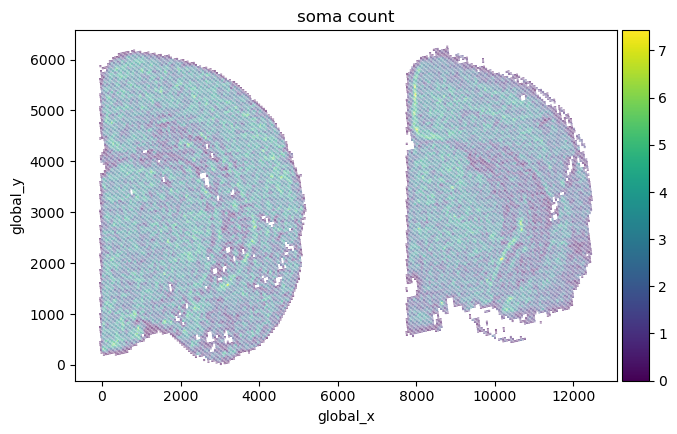

In [ ]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="soma_count")
plt.show()

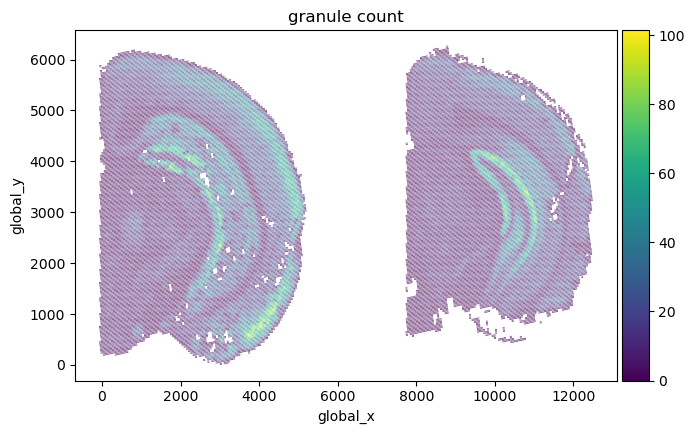

In [12]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="granule_count")
plt.show()

In [7]:
feature_names

['count_pre-syn', 'count_post-syn', 'count_dendrites', 'count_mixed']

In [8]:
aux

{'granule_count': array([0., 0., 0., ..., 0., 0., 0.]),
 'soma_count': array([0., 0., 0., ..., 0., 0., 0.])}

In [ ]:
k = 5
gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
labels = gmm.fit_predict(X_scaled)

In [ ]:
spots.obs["soma_density"] = embeddings[:, -1]

spots.obs["subdomain"] = labels.astype(str)
spots.obs["subdomain"].value_counts()

In [ ]:
del spots.uns["subdomain_colors"]
sc.pl.scatter(spots, x="global_x", y="global_y", color="subdomain", title="Subdomains")

In [ ]:
sc.pl.scatter(spots, x="global_x", y="global_y", color="soma_density", title="Subdomains")